In [104]:
import json
import os
import time
import urllib

import ee
import folium
import gdown
import geemap.foliumap as geemap
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import rasterio
import requests
import rioxarray
import seaborn
import xarray as xr
from helpers.alphaearth_helpers import *
from helpers.simplecube import load_xarray, save_xarray, simple_cube
from helpers.simplecube_helpers import *
from pyproj import Transformer
from rasterio.features import rasterize
from rasterio.transform import Affine
from scipy.interpolate import RectBivariateSpline
from scipy.signal import savgol_filter
from shapely import wkt
from shapely.geometry import MultiPoint, MultiPolygon, Point, Polygon
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, RobustScaler

test_tile_path = "./dataset/test_tile/"
roi_tile_path = "./dataset/roi_tiles/"
samples_path = "./dataset/samples/"

year = 2024

ee.Authenticate()
ee.Initialize(project="vital-wavelet-217112")
dataset_source = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
crs_str = dataset_source.first().projection().crs().getInfo()
base_proj = dataset_source.first().projection()

## Search Data

In [105]:
test_tile = gpd.read_file(f"{test_tile_path}/tile_C51L41_WGS84.gpkg")
if test_tile.crs != "EPSG:4326":
    test_tile = test_tile.to_crs(epsg=4326)
ee_roi_test = ee.FeatureCollection(json.loads(test_tile.to_json()))
test_tile

,id,i,col,row,area,area_rel,geometry
0,C51L41,4.0,51.0,41.0,7.650154e+08,98.996435,"POLYGON ((-61 -8.25, -61.25 -8.25, -61.25 -8, ..."


In [106]:
roi_tile_1 = gpd.read_file(f"{roi_tile_path}/tile_C51L34_Eco03_WGS84.gpkg")
if roi_tile_1.crs != "EPSG:4326":
    roi_tile_1 = roi_tile_1.to_crs(epsg=4326)
ee_roi_1 = ee.FeatureCollection(json.loads(roi_tile_1.to_json()))
roi_tile_1

,id,i,col,row,area,area_rel,geometry
0,C51L34,4.0,51.0,34.0,7.613232e+08,98.518646,"POLYGON ((-61 -10, -61.25 -10, -61.25 -9.75, -..."


In [107]:
roi_tile_2 = gpd.read_file(f"{roi_tile_path}/tile_C60L63_Eco01_WGS84.gpkg")
if roi_tile_2.crs != "EPSG:4326":
    roi_tile_2 = roi_tile_2.to_crs(epsg=4326)
ee_roi_2 = ee.FeatureCollection(json.loads(roi_tile_2.to_json()))
roi_tile_2

,id,i,col,row,area,area_rel,geometry
0,C60L63,8.0,60.0,63.0,7.719616e+08,99.895305,"POLYGON ((-58.75 -2.75, -59 -2.75, -59 -2.5, -..."


In [108]:
dataset_test = dataset_source.filterDate(f'{year}-01-01', f'{year}-12-31').filterBounds(ee_roi_test).mosaic().clip(ee_roi_test)
pca_image_test = calculate_pca_rgb(dataset_test, ee_roi_test, scale=10)

dataset_roi_1 = dataset_source.filterDate(f'{year}-01-01', f'{year}-12-31').filterBounds(ee_roi_1).mosaic().clip(ee_roi_1)
pca_image_roi_1 = calculate_pca_rgb(dataset_roi_1, ee_roi_1, scale=10)

dataset_roi_2 = dataset_source.filterDate(f'{year}-01-01', f'{year}-12-31').filterBounds(ee_roi_2).mosaic().clip(ee_roi_2)
pca_image_roi_2 = calculate_pca_rgb(dataset_roi_2, ee_roi_2, scale=10)

## Build and save Mosaics

In [110]:
# emb_style = {
#     "bands": ["A00", "A16", "A09"],
#     "min": -0.2,
#     "max": 0.2,
# }

# pca_style = {
#     'bands': ['R', 'G', 'B'],
#     'min': 0,
#     'max': 1
# }

# Map = geemap.Map(ee_initialize=False)
# Map.centerObject(ee_roi, 12)

# # ============================= Roi test
# tile = test_tile
# ee_roi = ee_roi_test
# dataset = dataset_test
# pca_image = pca_image_test

# ee_fc_roi_ = ee_roi.style(
#     color='FF0000',      # Cor da borda (Vermelho)
#     width=2,             # Espessura da linha
#     fillColor='00000000' # Transparente (8 dígitos hex: RRGGBBAA)
# )
# # Adicionar as camadas ao mapa
# Map.addLayer(ee_fc_roi_, {}, f'Region of Interest {tile.iloc[0].id}')
# Map.addLayer(dataset, emb_style, f"AlphaEarth Mosaic {tile.iloc[0].id}")
# Map.addLayer(pca_image, pca_style, f'AlphaEarth MOsaic PCA (RGB) {tile.iloc[0].id}')

# # ============================= Roi 1
# tile = roi_tile_1
# ee_roi = ee_roi_1
# dataset = dataset_roi_1
# pca_image = pca_image_roi_1

# ee_fc_roi_ = ee_roi.style(
#     color='FF0000',      # Cor da borda (Vermelho)
#     width=2,             # Espessura da linha
#     fillColor='00000000' # Transparente (8 dígitos hex: RRGGBBAA)
# )
# # Adicionar as camadas ao mapa
# Map.addLayer(ee_fc_roi_, {}, f'Region of Interest {tile.iloc[0].id}')
# Map.addLayer(dataset, emb_style, f"AlphaEarth Mosaic {tile.iloc[0].id}")
# Map.addLayer(pca_image, pca_style, f'AlphaEarth MOsaic PCA (RGB) {tile.iloc[0].id}')

# # ============================= Roi 2
# tile = roi_tile_2
# ee_roi = ee_roi_2
# dataset = dataset_roi_2
# pca_image = pca_image_roi_2

# ee_fc_roi_ = ee_roi.style(
#     color='FF0000',      # Cor da borda (Vermelho)
#     width=2,             # Espessura da linha
#     fillColor='00000000' # Transparente (8 dígitos hex: RRGGBBAA)
# )
# # Adicionar as camadas ao mapa
# Map.addLayer(ee_fc_roi_, {}, f'Region of Interest {tile.iloc[0].id}')
# Map.addLayer(dataset, emb_style, f"AlphaEarth Mosaic {tile.iloc[0].id}")
# Map.addLayer(pca_image, pca_style, f'AlphaEarth MOsaic PCA (RGB) {tile.iloc[0].id}')

# Map

In [111]:
drive_folder = 'EarthEngine_AlphaEarth'

# ============================= Roi Test
tile = test_tile
ee_roi = ee_roi_test
dataset = dataset_test

tile = test_tile
output_file_test = f'alphaearth_{year}_{tile.iloc[0].id}'

# task = ee.batch.Export.image.toDrive(
#     image=dataset,
#     description=output_file_test,
#     folder=drive_folder,
#     fileNamePrefix=output_file_test,
#     region=ee_roi.geometry(),
#     scale=10,
#     maxPixels=1e13,
#     fileFormat='GeoTIFF'
# )

# task.start()
# print(f"Tarefa de exportação iniciada (ID: {task.id}).")
print(f"{output_file_test}.tif")

# while task.active():
#     print(f"Status: {task.status()['state']}...", end="\r")
#     time.sleep(10)

# print(f"\nFinalizado com status: {task.status()['state']}")

# ============================= Roi 1
tile = roi_tile_1
ee_roi = ee_roi_1
dataset = dataset_roi_1

output_file_roi_1 = f'alphaearth_{year}_{tile.iloc[0].id}'

# task = ee.batch.Export.image.toDrive(
#     image=dataset,
#     description=output_file_roi_1,
#     folder=drive_folder,
#     fileNamePrefix=output_file_roi_1,
#     region=ee_roi.geometry(),
#     scale=10,
#     maxPixels=1e13,
#     fileFormat='GeoTIFF'
# )

# task.start()
# print(f"Tarefa de exportação iniciada (ID: {task.id}).")
print(f"{output_file_roi_1}.tif")

# while task.active():
#     print(f"Status: {task.status()['state']}...", end="\r")
#     time.sleep(10)

# print(f"\nFinalizado com status: {task.status()['state']}")

# ============================= Roi 2
tile = roi_tile_2
ee_roi = ee_roi_2
dataset = dataset_roi_2

output_file_roi_2 = f'alphaearth_{year}_{tile.iloc[0].id}'

# task = ee.batch.Export.image.toDrive(
#     image=dataset,
#     description=output_file_roi_2,
#     folder=drive_folder,
#     fileNamePrefix=output_file_roi_2,
#     region=ee_roi.geometry(),
#     scale=10,
#     maxPixels=1e13,
#     fileFormat='GeoTIFF'
# )

# task.start()
# print(f"Tarefa de exportação iniciada (ID: {task.id}).")
print(f"{output_file_roi_2}.tif")

# while task.active():
#     print(f"Status: {task.status()['state']}...", end="\r")
#     time.sleep(10)

# print(f"\nFinalizado com status: {task.status()['state']}")

alphaearth_2024_C51L41.tif
alphaearth_2024_C51L34.tif
alphaearth_2024_C60L63.tif


In [112]:
# output_dir = "./dataset/rasters/"
# os.makedirs(output_dir, exist_ok = True)

# # Link público de compartilhamento
# urls = [
#     "https://drive.google.com/file/d/1hbUxMYHSpbTbup4ZF840WecIkrxTW3ie/view?usp=drive_link",
#     "https://drive.google.com/file/d/1dan5TAuiFh2YS0ZBpkVWuiIcE2nU2RZU/view?usp=drive_link",
#     "https://drive.google.com/file/d/1Uw4DVhjtbY-XIBPxQAfimdm_qa5M2wrA/view?usp=drive_link"
# ]

# gdown.download(urls[0], f"{output_dir}{output_file_test}.tif", quiet=False)

# gdown.download(urls[1], f"{output_dir}{output_file_roi_1}.tif", quiet=False)

# gdown.download(urls[2], f"{output_dir}{output_file_roi_2}.tif", quiet=False)

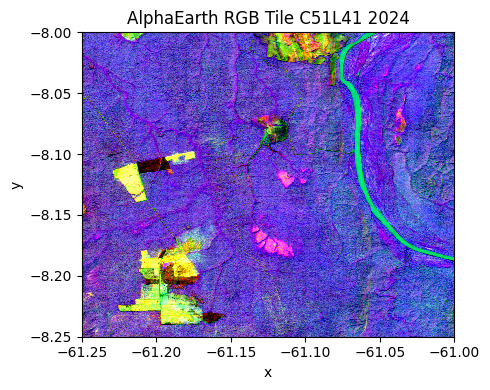

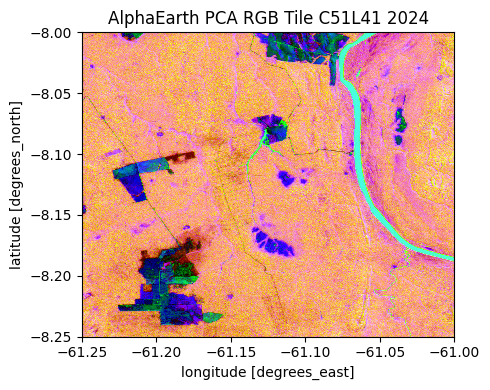

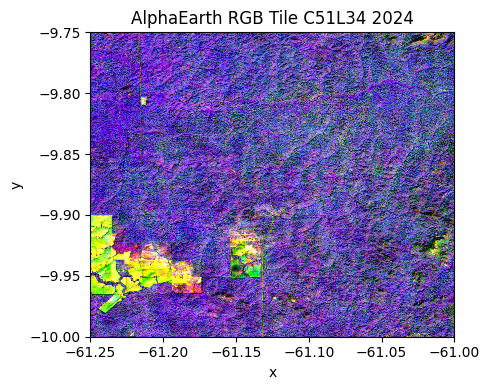

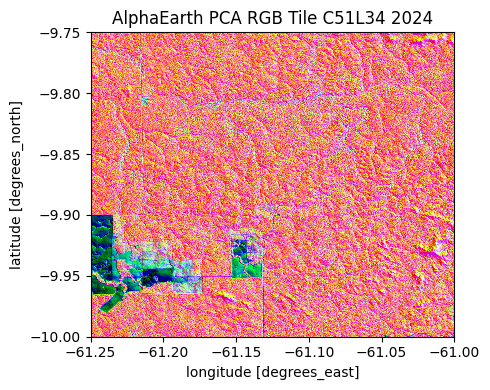

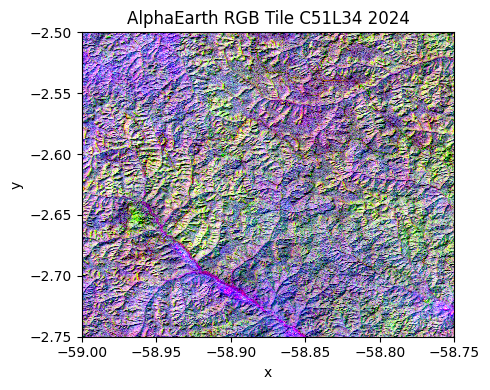

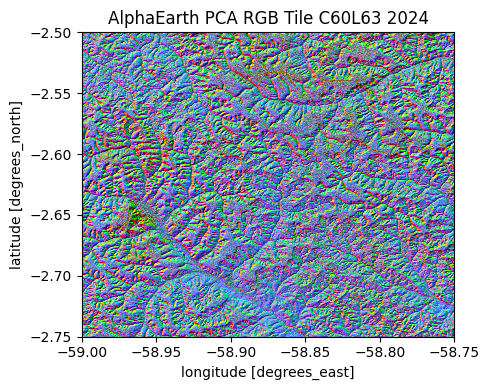

In [77]:
bands_ = [1, 5, 10]

# ============================= Roi test
alphaearth_roi_test = rioxarray.open_rasterio(f"{output_dir}{output_file_test}.tif", masked=True)
# alphaearth_roi_test_pca = compute_pca_rgb(alphaearth_roi_test, n_components=3, p_min=2.0, p_max=98.0)
# alphaearth_roi_test_pca.rio.to_raster(f"{output_dir}{output_file_test}_pca.tif", compress="lzw")
alphaearth_roi_test_pca = rioxarray.open_rasterio(f"{output_dir}{output_file_test}_pca.tif", masked=True)
alphaearth_roi_test_pca = alphaearth_roi_test_pca.rio.reproject(WGS84_WKT)
plot_xarray_(
    alphaearth_roi_test,
    bands = bands_,
    title=f"AlphaEarth RGB Tile {test_tile.iloc[0].id} {year}",
    figsize=(5, 4)
)

plot_xarray_(
    alphaearth_roi_test_pca,
    title=f"AlphaEarth PCA RGB Tile {test_tile.iloc[0].id} {year}",
    figsize=(5, 4)
)

# ============================= Roi 1
alphaearth_roi_1 = rioxarray.open_rasterio(f"{output_dir}{output_file_roi_1}.tif", masked=True)
# alphaearth_roi_1_pca = compute_pca_rgb(alphaearth_roi_1, n_components=3, p_min=2.0, p_max=98.0)
# alphaearth_roi_1_pca.rio.to_raster(f"{output_dir}{output_file_roi_1}_pca.tif", compress="lzw")
alphaearth_roi_1_pca = rioxarray.open_rasterio(f"{output_dir}{output_file_roi_1}_pca.tif", masked=True)
alphaearth_roi_1_pca = alphaearth_roi_1_pca.rio.reproject(WGS84_WKT)
plot_xarray_(
    alphaearth_roi_1,
    bands = bands_,
    title=f"AlphaEarth RGB Tile {roi_tile_1.iloc[0].id} {year}",
    figsize=(5, 4)
)

plot_xarray_(
    alphaearth_roi_1_pca,
    title=f"AlphaEarth PCA RGB Tile {roi_tile_1.iloc[0].id} {year}",
    figsize=(5, 4)
)

# ============================= Roi 2
alphaearth_roi_2 = rioxarray.open_rasterio(f"{output_dir}{output_file_roi_2}.tif", masked=True)
# alphaearth_roi_2_pca = compute_pca_rgb(alphaearth_roi_2, n_components=3, p_min=2.0, p_max=98.0)
# alphaearth_roi_2_pca.rio.to_raster(f"{output_dir}{output_file_roi_2}_pca.tif", compress="lzw")
alphaearth_roi_2_pca = rioxarray.open_rasterio(f"{output_dir}{output_file_roi_2}_pca.tif", masked=True)
alphaearth_roi_2_pca = alphaearth_roi_2_pca.rio.reproject(WGS84_WKT)
plot_xarray_(
    alphaearth_roi_2,
    bands = bands_,
    title=f"AlphaEarth RGB Tile {roi_tile_2.iloc[0].id} {year}",
    figsize=(5, 4)
)

plot_xarray_(
    alphaearth_roi_2_pca,
    title=f"AlphaEarth PCA RGB Tile {roi_tile_2.iloc[0].id} {year}",
    figsize=(5, 4)
)

## Extract embeddings for samples

In [ ]:
# ============================= Roi test
tile = test_tile
tile_id = tile.iloc[0].id
samples_test_tile = gpd.read_file(f"{samples_path}samples_{tile_id}_{year}_points.csv")

samples = samples_test_tile
samples["geometry"] = samples["geometry"].apply(wkt.loads)
samples = gpd.GeoDataFrame(samples, geometry="geometry", crs="EPSG:4326")
geojson = json.loads(samples.to_json())
ee_samples = ee.FeatureCollection(geojson)

# # mean dos pixels por polígono
# extracted_fc = dataset_test.reduceRegions(
#    collection = ee_samples,
#    reducer = ee.Reducer.mean(),
#    scale = 10,
#    tileScale = 4
# )
# por pixel
extracted_pixels_fc = dataset_test.sampleRegions(
    collection = ee_samples,
    properties = ["label", "year", "tile"],
    scale = 10,
    geometries = True,
    tileScale = 4
)

result_gdf = geemap.ee_to_gdf(extracted_pixels_fc)
emb_columns = list([(f"A{i}" if i > 9 else f"A0{i}") for i in range(0, 64)])
samples_embeddings = result_gdf[["geometry", "tile", "year", "label"] + emb_columns]
samples_embeddings.to_csv(f"./dataset/samples/samples_{tile_id}_{year}_embeddings_alphaearth_pixel.csv", index=False)

samples_test_tile = samples_test_embeddings.copy()

# ============================= Roi 1
tile = roi_tile_1
tile_id = tile.iloc[0].id
samples_roi_tile_1 = gpd.read_file(f"{samples_path}samples_{tile_id}_{year}_points.csv")

samples = samples_roi_tile_1
samples["geometry"] = samples["geometry"].apply(wkt.loads)
samples = gpd.GeoDataFrame(samples, geometry="geometry", crs="EPSG:4326")
geojson = json.loads(samples.to_json())
ee_samples = ee.FeatureCollection(geojson)

# # mean dos pixels por polígono
# extracted_fc = dataset_roi_1.reduceRegions(
#    collection = ee_samples,
#    reducer = ee.Reducer.mean(),
#    scale = 10,
#    tileScale = 4
# )
# por pixel
extracted_pixels_fc = dataset_roi_1.sampleRegions(
    collection = ee_samples,
    properties = ["label", "year", "tile"],
    scale = 10,
    geometries = True,
    tileScale = 4
)

result_gdf = geemap.ee_to_gdf(extracted_pixels_fc)
emb_columns = list([(f"A{i}" if i > 9 else f"A0{i}") for i in range(0, 64)])
samples_embeddings = result_gdf[["geometry", "tile", "year", "label"] + emb_columns]
samples_embeddings.to_csv(f"./dataset/samples/samples_{tile_id}_{year}_embeddings_alphaearth_pixel.csv", index=False)

samples_roi_tile_1 = samples_embeddings.copy()

# ============================= Roi 2
tile = roi_tile_2
tile_id = tile.iloc[0].id
samples_roi_tile_2 = gpd.read_file(f"{samples_path}samples_{tile_id}_{year}_points.csv")

samples = samples_roi_tile_2
samples["geometry"] = samples["geometry"].apply(wkt.loads)
samples = gpd.GeoDataFrame(samples, geometry="geometry", crs="EPSG:4326")
geojson = json.loads(samples.to_json())
ee_samples = ee.FeatureCollection(geojson)

# # mean dos pixels por polígono
# extracted_fc = dataset_roi_2.reduceRegions(
#    collection = ee_samples,
#    reducer = ee.Reducer.mean(),
#    scale = 10,
#    tileScale = 4
# )
# por pixel
extracted_pixels_fc = dataset_roi_2.sampleRegions(
    collection = ee_samples,
    properties = ["label", "year", "tile"],
    scale = 10,
    geometries = True,
    tileScale = 4
)

result_gdf = geemap.ee_to_gdf(extracted_pixels_fc)
emb_columns = list([(f"A{i}" if i > 9 else f"A0{i}") for i in range(0, 64)])
samples_embeddings = result_gdf[["geometry", "tile", "year", "label"] + emb_columns]
samples_embeddings.to_csv(f"./dataset/samples/samples_{tile_id}_{year}_embeddings_alphaearth_pixel.csv", index=False)

samples_roi_tile_2 = samples_embeddings.copy()

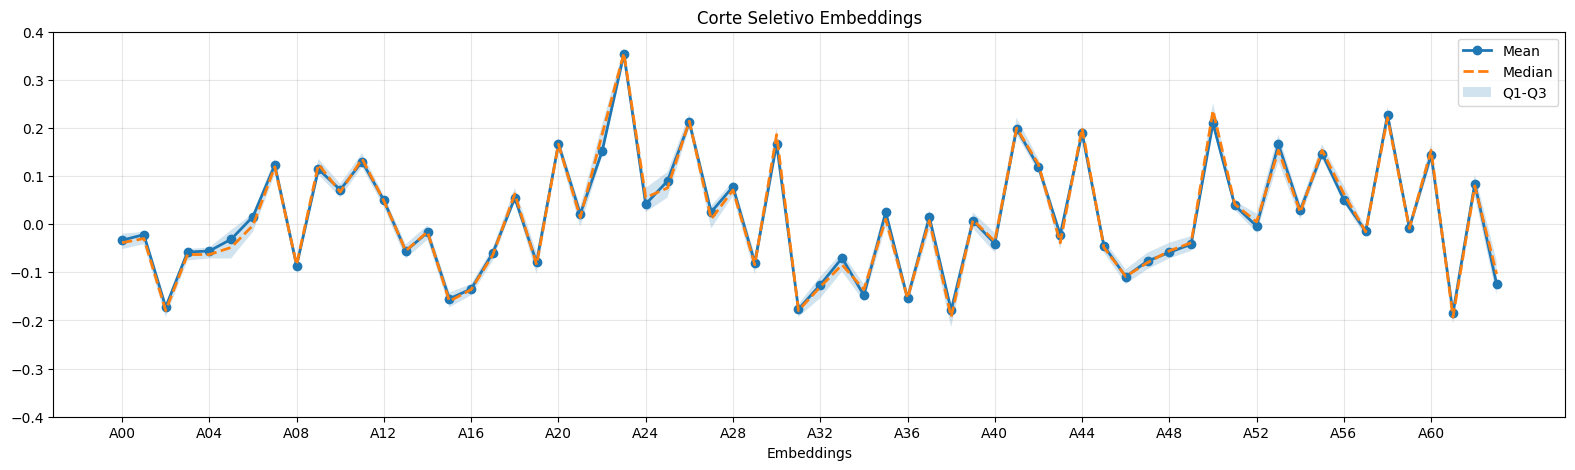

In [114]:
samples = samples_test_tile
labels = set(samples["label"])
for label in labels:
    data_ = samples[samples["label"] == label]
    generatePlotFigPatterns(data_[emb_columns], label)

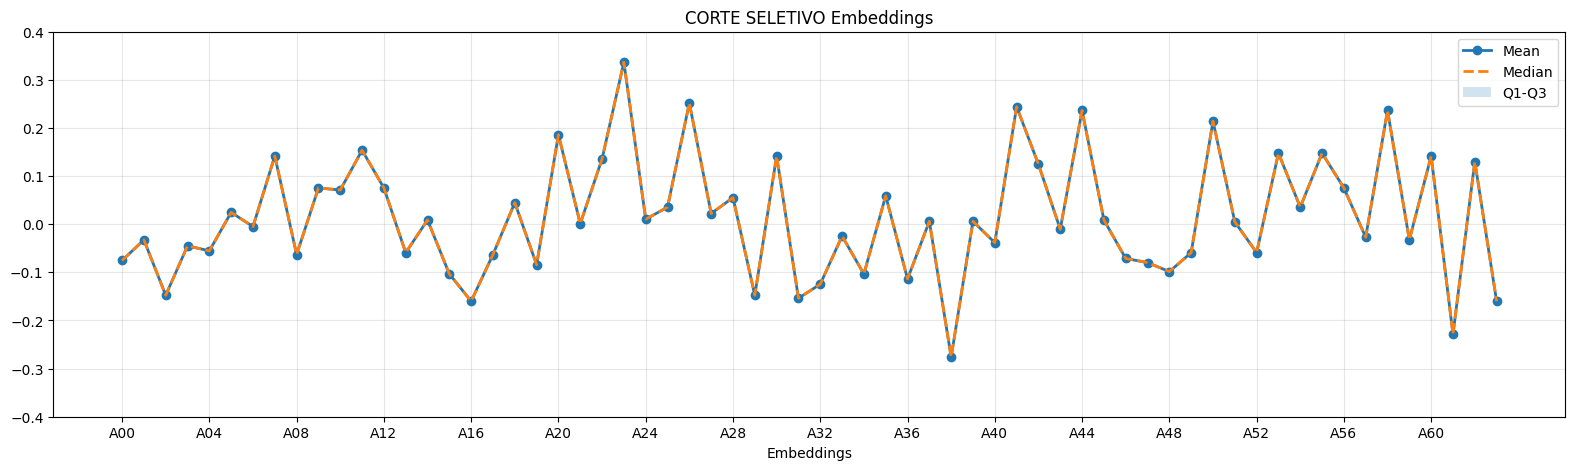

In [115]:
samples = samples_roi_tile_1
labels = set(samples["label"])
for label in labels:
    data_ = samples[samples["label"] == label]
    generatePlotFigPatterns(data_[emb_columns], label)

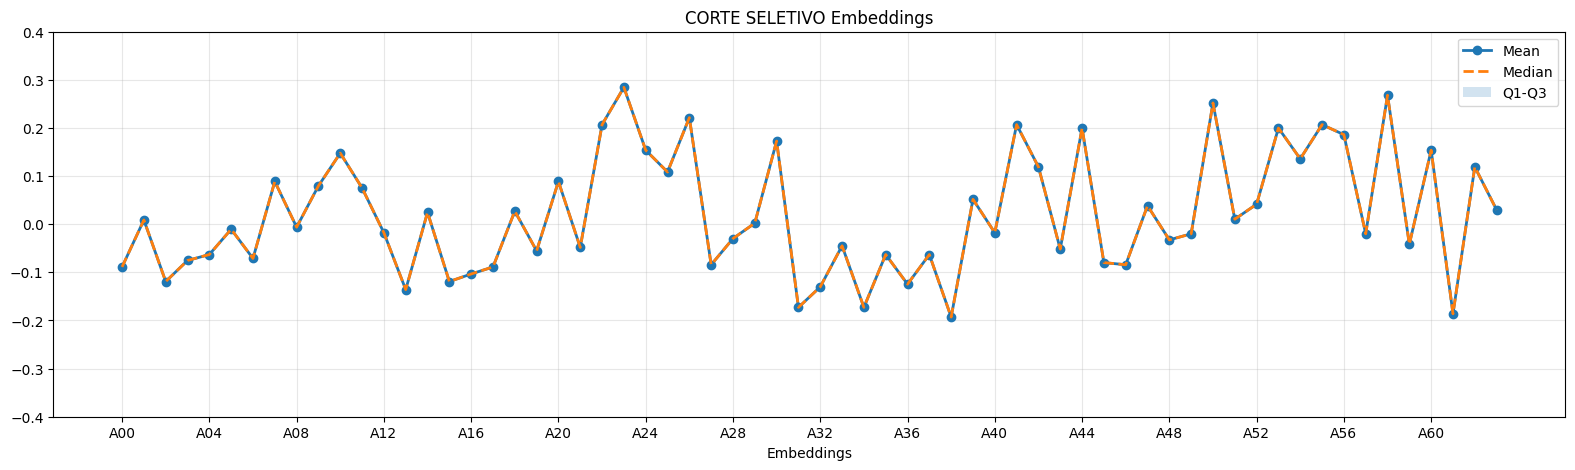

In [116]:
samples = samples_roi_tile_2
labels = set(samples["label"])
for label in labels:
    data_ = samples[samples["label"] == label]
    generatePlotFigPatterns(data_[emb_columns], label)

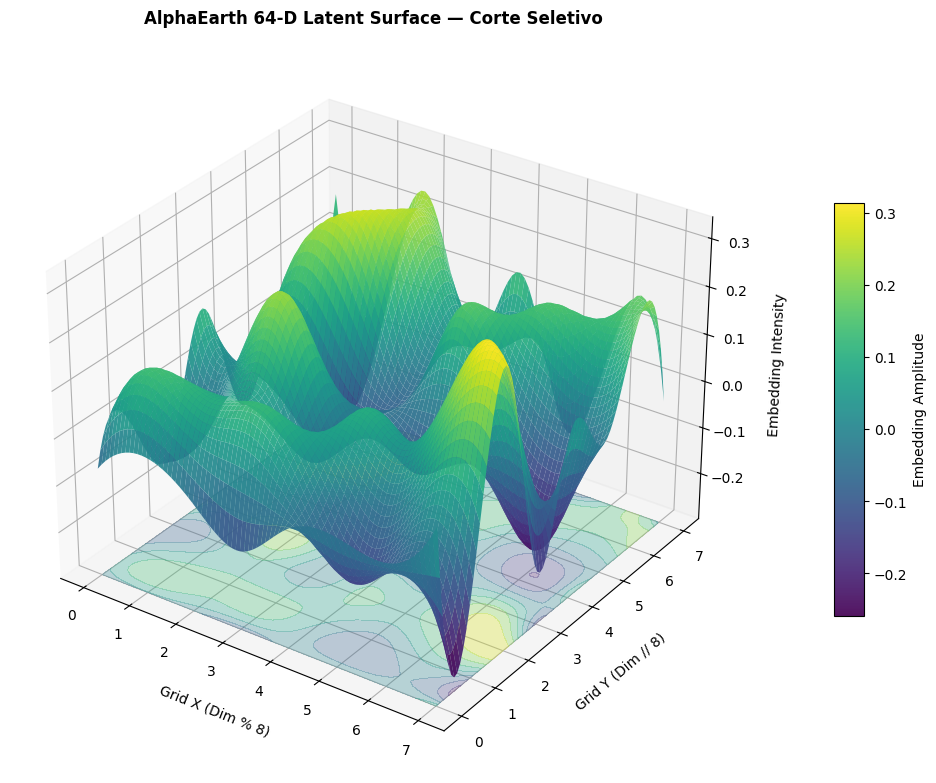

In [102]:
labels = set(samples_roi_tile_2_embeddings["label"])
for label in labels:
    data_ = samples_roi_tile_2_embeddings[samples_roi_tile_2_embeddings["label"] == label]
    plot_alphaearth_embedding_3d(data_[emb_columns], label)